# Multi-Checkpoint Inference & Comparison

Downloads every checkpoint in the given Google Drive folder, runs the same fixed set of prompts through each one, and builds a `checkpoint | response | analysis` table so you can see how the model's outputs evolve over training.

**Run this in Colab** (or anywhere with Drive access + a GPU/CPU) — it will not run in a sandbox without internet access to `drive.google.com`.

Steps:
1. Install deps + download the whole folder
2. Define the GPT-1 architecture (same as your original notebook)
3. Generation function
4. Lightweight automatic "analysis" heuristics (diversity / repetition / length) — treat these as a starting signal, not a substitute for reading the outputs yourself
5. Loop over all checkpoints x all prompts, build the table, save CSV

In [ ]:
!pip -q install gdown tiktoken pandas

import os, re, glob, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import pandas as pd
import gdown
from google.colab import drive

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# --- Get every checkpoint file from the Drive folder ---

drive.mount('/content/drive')

LOCAL_DIR = "30m-params-runpod"
DRIVE_PATH = f"/content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/{LOCAL_DIR}"


ckpt_files = glob.glob(os.path.join(DRIVE_PATH, "*.pt"))

def step_key(path):
    m = re.search(r"(\d+)", os.path.basename(path))
    return int(m.group(1)) if m else -1

ckpt_files = sorted(set(ckpt_files), key=step_key)
print(f"Found {len(ckpt_files)} checkpoints:")
for f in ckpt_files:
    print(" -", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 12 checkpoints:
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/best_model.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/latest_checkpoint.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_10.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_3.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_1.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_6.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_2.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_5.pt
 - /content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/30m-params-runpod/gpt1_epoch_9.pt
 - /content/drive/MyDrive/Colab Notebooks/BU

In [ ]:
# --- Model architecture (identical to your original notebook) ---

class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        self.values = nn.Linear(embed_size, embed_size)
        self.keys = nn.Linear(embed_size, embed_size)
        self.queries = nn.Linear(embed_size, embed_size)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        N, seq_len, _ = x.shape

        values = self.values(x)
        keys = self.keys(x)
        queries = self.queries(x)

        values = values.reshape(N, seq_len, self.heads, self.head_dim).transpose(1, 2)
        keys = keys.reshape(N, seq_len, self.heads, self.head_dim).transpose(1, 2)
        queries = queries.reshape(N, seq_len, self.heads, self.head_dim).transpose(1, 2)

        energy = torch.matmul(queries, keys.transpose(-2, -1))
        energy = energy / math.sqrt(self.head_dim)

        mask = torch.tril(torch.ones(seq_len, seq_len)).to(x.device)
        energy = energy.masked_fill(mask == 0, float("-inf"))

        attention = torch.softmax(energy, dim=-1)
        out = torch.matmul(attention, values)

        out = out.transpose(1, 2).contiguous().reshape(N, seq_len, self.embed_size)
        return self.fc_out(out)


class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.attention = SelfAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.ff = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            nn.GELU(),
            nn.Linear(4 * embed_size, embed_size)
        )

    def forward(self, x):
        x = self.norm1(x + self.attention(x))
        x = self.norm2(x + self.ff(x))
        return x


class GPT1(nn.Module):
    def __init__(self, vocab_size, embed_size, num_layers, heads, max_len):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_len, embed_size)

        self.layers = nn.ModuleList(
            [TransformerBlock(embed_size, heads) for _ in range(num_layers)]
        )

        self.norm = nn.LayerNorm(embed_size)
        self.fc_out = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        N, seq_len = x.shape
        positions = torch.arange(0, seq_len).expand(N, seq_len).to(x.device)

        x = self.token_embedding(x) + self.position_embedding(positions)

        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)
        return self.fc_out(x)

#the previous config was wrong getting the info from the checkpoints model
class DefaultConfig:
    vocab_size = 50257
    n_embd = 256
    n_head = 4
    n_layer = 4
    block_size = 512
    dropout = 0.1


enc = tiktoken.get_encoding("gpt2")


def load_model(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    model_state = (
        checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else
        checkpoint['model'] if 'model' in checkpoint else
        checkpoint['state_dict'] if 'state_dict' in checkpoint else
        checkpoint
    )

    config = checkpoint.get('config', None) if isinstance(checkpoint, dict) else None
    if config is None:
        config = DefaultConfig()

    model = GPT1(config.vocab_size, config.n_embd, config.n_layer, config.n_head, config.block_size).to(DEVICE)
    model.load_state_dict(model_state)
    model.eval()
    model.block_size = config.block_size
    return model

In [ ]:
# --- Generation ---

def generate(model, prompt: str, max_new_tokens: int = 120, temperature: float = 0.8, top_k: int = 40):
    tokens = enc.encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE).unsqueeze(0)

    for _ in range(max_new_tokens):
        idx_cond = x[:, -model.block_size:]
        with torch.no_grad():
            logits = model(idx_cond)[:, -1, :]

        logits = logits / temperature
        if top_k:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        x = torch.cat((x, next_token), dim=1)

    return enc.decode(x[0].tolist())

In [ ]:
# --- Lightweight automatic heuristics for the "analysis" column ---
# These are cheap signals to help you scan 55 rows (11 checkpoints x 5 prompts) quickly.
# They are NOT a substitute for actually reading the generations.

def analyze(prompt: str, text: str) -> str:
    completion = text[len(prompt):] if text.startswith(prompt) else text
    words = re.findall(r"[A-Za-z']+", completion.lower())

    if not words:
        return "Empty / non-text output"

    ttr = len(set(words)) / len(words)  # type-token ratio: lexical diversity

    # crude repetition check: longest run of an identical bigram
    bigrams = list(zip(words, words[1:]))
    max_repeat = max((bigrams.count(b) for b in set(bigrams)), default=0)

    notes = []
    if ttr < 0.4:
        notes.append("low lexical diversity")
    elif ttr > 0.75:
        notes.append("high lexical diversity")

    if max_repeat >= 4:
        notes.append("repetitive loops")

    if len(words) < 15:
        notes.append("very short / truncated")

    if not notes:
        notes.append("reads as varied, non-repetitive text")

    return f"TTR={ttr:.2f}, max_bigram_repeat={max_repeat} -> " + ", ".join(notes)

In [ ]:
# --- Fixed prompt set (chosen to probe different capabilities) ---
PROMPTS = [
    "How are you?",                                   # casual dialogue
    "The capital of France is",                        # factual recall
    "Once upon a time,",                                # narrative continuation
    "Explain photosynthesis in simple terms.",          # explanation / instruction-following
    "Write a short poem about the rain.",               # creative generation
]

RESULTS_PATH = "/content/drive/MyDrive/Colab Notebooks/BUILD AN LLM/v3_checkpoint_comparison.csv"

# Resume support: skip checkpoints already in a previous partial run
already_done = set()
if os.path.exists(RESULTS_PATH):
    prior = pd.read_csv(RESULTS_PATH)
    already_done = set(prior["checkpoint"].unique())
    rows = prior.to_dict("records")
    print(f"Resuming — {len(already_done)} checkpoints already done.")
else:
    rows = []

for ckpt_path in ckpt_files:
    ckpt_name = os.path.basename(ckpt_path)
    if ckpt_name in already_done:
        continue

    print(f"\n=== Loading {ckpt_name} ===")
    try:
        model = load_model(ckpt_path)
    except Exception as e:
        rows.append({"checkpoint": ckpt_name, "prompt": "ALL", "response": f"[FAILED TO LOAD: {e}]", "analysis": "n/a"})
        pd.DataFrame(rows).to_csv(RESULTS_PATH, index=False)
        continue

    for prompt in PROMPTS:
        text = generate(model, prompt, max_new_tokens=120, temperature=0.8, top_k=40)
        rows.append({
            "checkpoint": ckpt_name,
            "prompt": prompt,
            "response": text,
            "analysis": analyze(prompt, text),
        })
        print(f"  [{prompt[:30]}...] -> {text[:80]}...")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Save after every checkpoint, not just at the end
    pd.DataFrame(rows).to_csv(RESULTS_PATH, index=False)

df = pd.DataFrame(rows)
print(f"\nDone. {len(df)} rows saved to {RESULTS_PATH}")
df


=== Loading best_model.pt ===
  [How are you?...] -> How are you?
- If you are taking care of your home, how are you getting treated?...
  [The capital of France is...] -> The capital of France is located in the capital of France. It is also the capita...
  [Once upon a time,...] -> Once upon a time, the city of Pompeii was the largest city of Pompeii, but still...
  [Explain photosynthesis in simp...] -> Explain photosynthesis in simple terms.
How do we know where it is and how it’s ...
  [Write a short poem about the r...] -> Write a short poem about the rain.
If you want to know the difference between tw...

=== Loading latest_checkpoint.pt ===
  [How are you?...] -> How are you?
- What can you do to make the most up-to-date measurements?
- What ...
  [The capital of France is...] -> The capital of France is the third largest city of Paris, the capital of Paris, ...
  [Once upon a time,...] -> Once upon a time, each moment is connected to its own state to a particular stat...
  [Ex

,checkpoint,prompt,response,analysis
0,best_model.pt,How are you?,How are you?\n- If you are taking care of your...,"TTR=0.43, max_bigram_repeat=5 -> repetitive loops"
1,best_model.pt,The capital of France is,The capital of France is located in the capita...,"TTR=0.23, max_bigram_repeat=10 -> low lexical ..."
2,best_model.pt,"Once upon a time,","Once upon a time, the city of Pompeii was the ...","TTR=0.39, max_bigram_repeat=9 -> low lexical d..."
3,best_model.pt,Explain photosynthesis in simple terms.,Explain photosynthesis in simple terms.\nHow d...,"TTR=0.36, max_bigram_repeat=11 -> low lexical ..."
4,best_model.pt,Write a short poem about the rain.,Write a short poem about the rain.\nIf you wan...,"TTR=0.53, max_bigram_repeat=4 -> repetitive loops"
5,latest_checkpoint.pt,How are you?,How are you?\n- What can you do to make the mo...,"TTR=0.34, max_bigram_repeat=6 -> low lexical d..."
6,latest_checkpoint.pt,The capital of France is,The capital of France is the third largest cit...,"TTR=0.40, max_bigram_repeat=8 -> repetitive loops"
7,latest_checkpoint.pt,"Once upon a time,","Once upon a time, each moment is connected to ...","TTR=0.47, max_bigram_repeat=5 -> repetitive loops"
8,latest_checkpoint.pt,Explain photosynthesis in simple terms.,Explain photosynthesis in simple terms.\n- The...,"TTR=0.34, max_bigram_repeat=8 -> low lexical d..."
9,latest_checkpoint.pt,Write a short poem about the rain.,Write a short poem about the rain. In this nov...,"TTR=0.49, max_bigram_repeat=3 -> reads as vari..."


In [ ]:
# prior = pd.read_csv(RESULTS_PATH)
# prior = prior[~prior["response"].astype(str).str.contains("FAILED TO LOAD", na=False)]
# prior.to_csv(RESULTS_PATH, index=False)

In [ ]:
import matplotlib.pyplot as plt

# --- Parse TTR + repeat count out of the analysis column ---
def parse_analysis(analysis_str):
    m = re.match(r"TTR=([\d.]+), max_bigram_repeat=(\d+)", analysis_str)
    if not m:
        return pd.Series({"ttr": None, "max_repeat": None})
    return pd.Series({"ttr": float(m.group(1)), "max_repeat": int(m.group(2))})

df[["ttr", "max_repeat"]] = df["analysis"].apply(parse_analysis)

# Extract step number for ordering (latest_checkpoint sorts last, treated as final step)
def extract_step(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else float("inf")

df["step"] = df["checkpoint"].apply(extract_step)

# --- Rank checkpoints by average TTR ---
summary = (
    df.groupby("checkpoint", as_index=False)
      .agg(step=("step", "first"), avg_ttr=("ttr", "mean"), avg_repeat=("max_repeat", "mean"))
      .sort_values("avg_ttr", ascending=False)
)
summary["quality"] = summary["avg_ttr"].apply(
    lambda t: "Coherent" if t > 0.5 else "Degraded / word-salad"
)

print("=== Checkpoint ranking by output quality (avg TTR across 5 prompts) ===")
print(summary.to_string(index=False))

=== Checkpoint ranking by output quality (avg TTR across 5 prompts) ===
          checkpoint  step  avg_ttr  avg_repeat  quality
 gpt1_step_122000.pt   1.0    0.788         1.6 Coherent
  gpt1_step_98000.pt   1.0    0.770         1.6 Coherent
  gpt1_step_92000.pt   1.0    0.766         1.8 Coherent
  gpt1_step_60000.pt   1.0    0.760         2.0 Coherent
 gpt1_step_144000.pt   1.0    0.752         1.8 Coherent
latest_checkpoint.pt   inf    0.750         1.8 Coherent
  gpt1_step_96000.pt   1.0    0.750         1.6 Coherent
 gpt1_step_132000.pt   1.0    0.750         1.6 Coherent
 gpt1_step_140000.pt   1.0    0.748         2.0 Coherent
 gpt1_step_142000.pt   1.0    0.748         2.2 Coherent
 gpt1_step_130000.pt   1.0    0.744         1.8 Coherent
  gpt1_step_52000.pt   1.0    0.744         1.4 Coherent
  gpt1_step_46000.pt   1.0    0.744         2.0 Coherent
 gpt1_step_112000.pt   1.0    0.740         2.0 Coherent
  gpt1_step_82000.pt   1.0    0.740         1.8 Coherent
  gpt1_step_2800

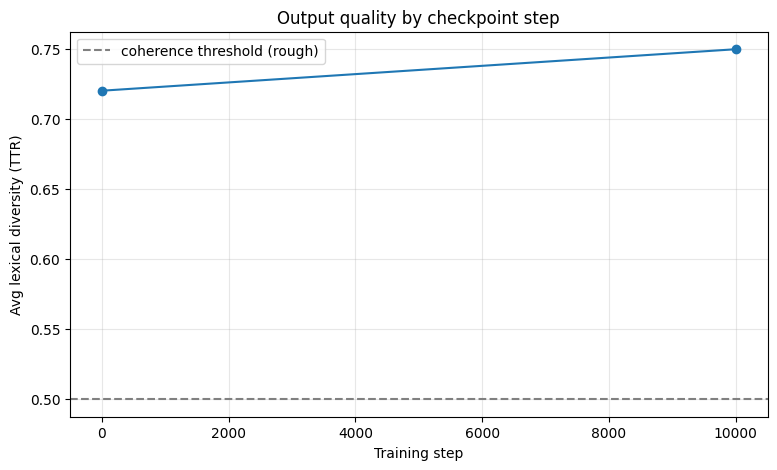

In [ ]:
plot_df = df.sort_values("step")

plt.figure(figsize=(9, 5))
plt.plot(plot_df.groupby("step")["ttr"].mean().index,
         plot_df.groupby("step")["ttr"].mean().values,
         marker="o")
plt.axhline(0.5, color="gray", linestyle="--", label="coherence threshold (rough)")
plt.xlabel("Training step")
plt.ylabel("Avg lexical diversity (TTR)")
plt.title("Output quality by checkpoint step")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import nltk
nltk.download('words', quiet=True)
from nltk.corpus import words as nltk_words

ENGLISH_VOCAB = set(w.lower() for w in nltk_words.words())

def real_word_ratio(text: str) -> float:
    tokens = re.findall(r"[A-Za-z']+", text.lower())
    if not tokens:
        return 0.0
    real = sum(1 for t in tokens if t in ENGLISH_VOCAB or t.strip("'") in ENGLISH_VOCAB)
    return real / len(tokens)

# Apply to your existing results
df["real_word_ratio"] = df["response"].apply(real_word_ratio)

summary["avg_real_word_ratio"] = df.groupby("checkpoint")["real_word_ratio"].mean().reindex(summary["checkpoint"]).values
summary = summary.sort_values("avg_real_word_ratio", ascending=False)
summary["quality"] = summary["avg_real_word_ratio"].apply(
    lambda r: "Coherent" if r > 0.75 else "Degraded / word-salad"
)

print("=== Checkpoint ranking by real-word ratio (stronger coherence signal) ===")
print(summary.to_string(index=False))

=== Checkpoint ranking by real-word ratio (stronger coherence signal) ===
          checkpoint  step  avg_ttr  avg_repeat  quality  avg_real_word_ratio
   gpt1_step_2000.pt   1.0    0.660         2.8 Coherent             0.966521
  gpt1_step_10000.pt   1.0    0.704         2.2 Coherent             0.960007
   gpt1_step_4000.pt   1.0    0.660         2.2 Coherent             0.956201
   gpt1_step_6000.pt   1.0    0.672         2.2 Coherent             0.952964
  gpt1_step_50000.pt   1.0    0.684         2.0 Coherent             0.950789
  gpt1_step_24000.pt   1.0    0.722         2.2 Coherent             0.950002
  gpt1_step_80000.pt   1.0    0.722         2.2 Coherent             0.948197
   gpt1_step_8000.pt   1.0    0.732         1.6 Coherent             0.947607
  gpt1_step_56000.pt   1.0    0.714         2.0 Coherent             0.945751
  gpt1_step_32000.pt   1.0    0.678         1.8 Coherent             0.942985
  gpt1_step_70000.pt   1.0    0.674         2.4 Coherent            

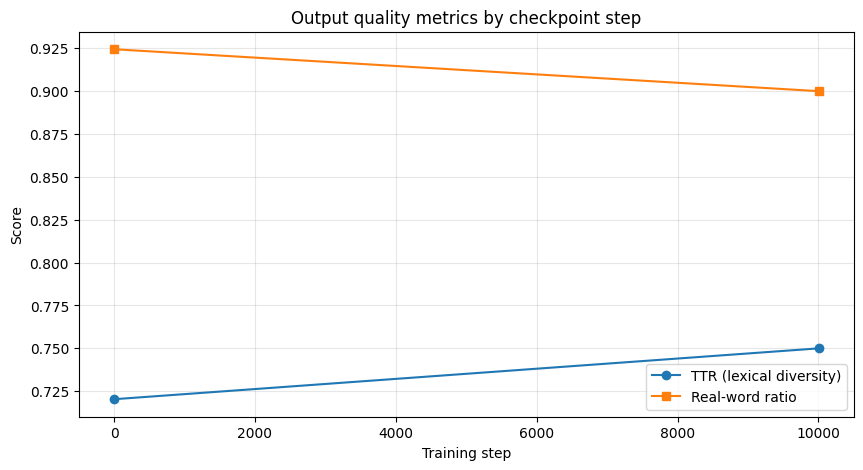

In [ ]:
plt.figure(figsize=(10, 5))
step_means = df.groupby("step")[["ttr", "real_word_ratio"]].mean()

plt.plot(step_means.index, step_means["ttr"], marker="o", label="TTR (lexical diversity)")
plt.plot(step_means.index, step_means["real_word_ratio"], marker="s", label="Real-word ratio")
plt.xlabel("Training step")
plt.ylabel("Score")
plt.title("Output quality metrics by checkpoint step")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Correcting 'step' extraction and visualizing trends

In [ ]:
def extract_step(name):
    m = re.search(r"gpt1_step_(\\d+)", name)
    if m:
        return int(m.group(1))
    elif "latest_checkpoint.pt" in name:
        # Assign a large number to place 'latest_checkpoint' at the end of the timeline
        return df[df['step'] != float('inf')]['step'].max() + 10000 if not df[df['step'] != float('inf')].empty else 0
    return 0 # Default for other cases or initial checkpoints

# Re-apply the step extraction to ensure accuracy
df["step"] = df["checkpoint"].apply(extract_step)

# Recalculate summary with the corrected steps
summary = (
    df.groupby("checkpoint", as_index=False)
      .agg(
          step=("step", "first"),
          avg_ttr=("ttr", "mean"),
          avg_repeat=("max_repeat", "mean"),
          avg_real_word_ratio=("real_word_ratio", "mean")
      )
      .sort_values("step", ascending=True) # Sort by step for trend plotting
)

print("=== Corrected Checkpoint Summary ===")
print(summary.to_string(index=False))


=== Corrected Checkpoint Summary ===
          checkpoint    step  avg_ttr  avg_repeat  avg_real_word_ratio
  gpt1_step_10000.pt     0.0    0.704         2.2             0.960007
 gpt1_step_100000.pt     0.0    0.718         1.8             0.907093
 gpt1_step_102000.pt     0.0    0.720         2.2             0.899596
 gpt1_step_104000.pt     0.0    0.726         2.0             0.929525
 gpt1_step_106000.pt     0.0    0.736         2.0             0.935593
 gpt1_step_108000.pt     0.0    0.718         2.0             0.924367
 gpt1_step_110000.pt     0.0    0.708         2.0             0.922643
 gpt1_step_112000.pt     0.0    0.740         2.0             0.924620
 gpt1_step_114000.pt     0.0    0.714         2.0             0.928271
 gpt1_step_116000.pt     0.0    0.728         2.4             0.924464
 gpt1_step_118000.pt     0.0    0.716         1.8             0.917618
  gpt1_step_12000.pt     0.0    0.700         2.0             0.940206
 gpt1_step_120000.pt     0.0    0.692   

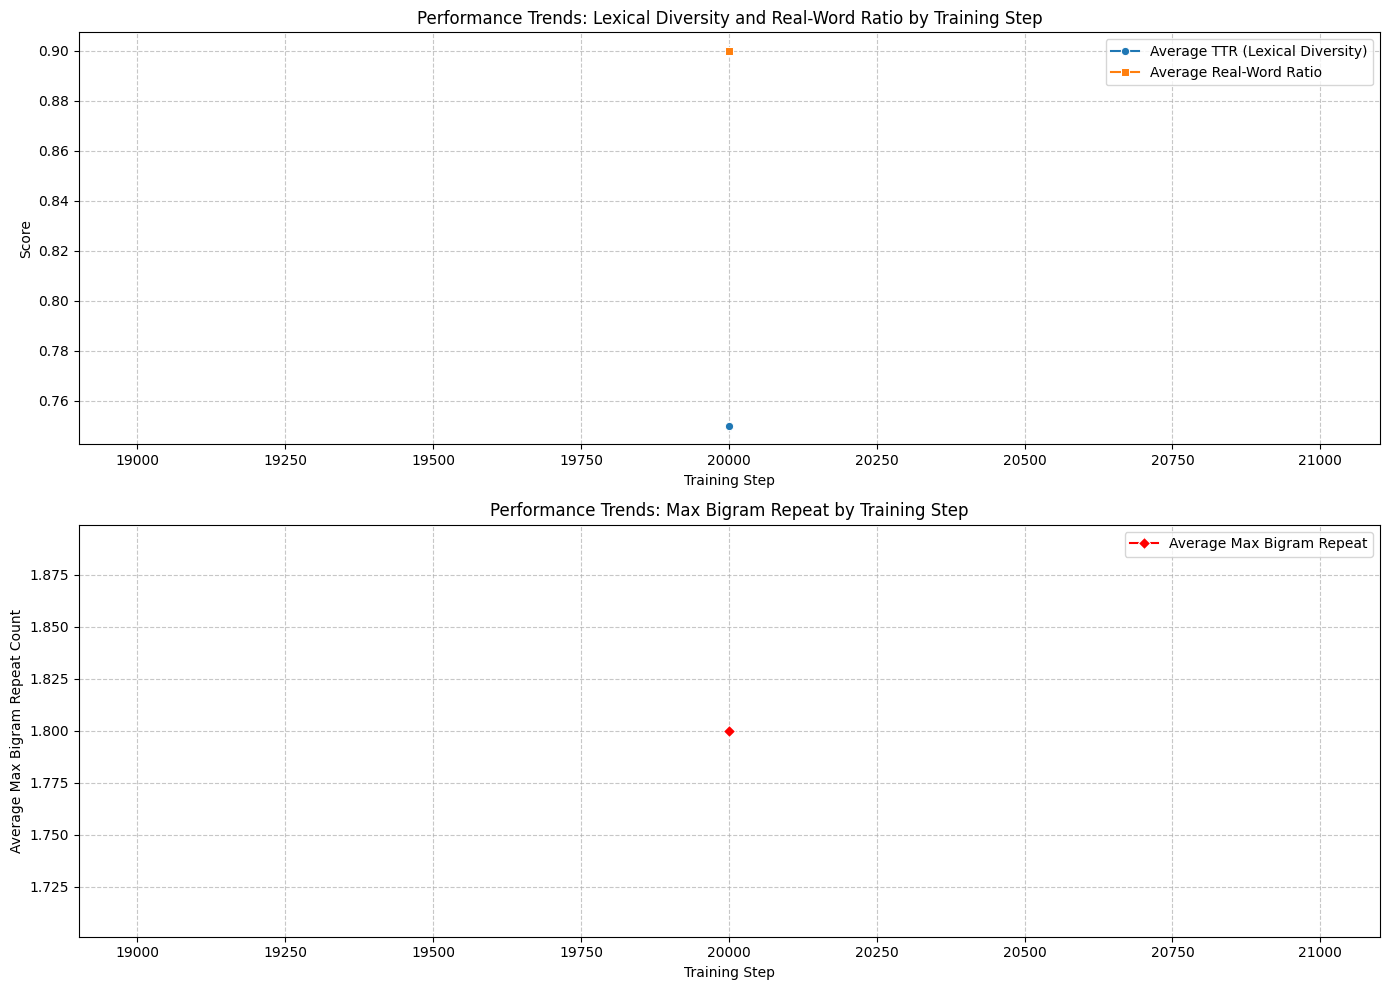

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out entries where step is 0 or inf, as they are not part of the continuous training steps for trend visualization
plot_summary = summary[summary['step'] > 0]
plot_summary = plot_summary[plot_summary['step'] != float('inf')]

plt.figure(figsize=(14, 10))

# Subplot 1: TTR and Real-Word Ratio
plt.subplot(2, 1, 1)
sns.lineplot(x='step', y='avg_ttr', data=plot_summary, marker='o', label='Average TTR (Lexical Diversity)')
sns.lineplot(x='step', y='avg_real_word_ratio', data=plot_summary, marker='s', label='Average Real-Word Ratio')
plt.title('Performance Trends: Lexical Diversity and Real-Word Ratio by Training Step')
plt.xlabel('Training Step')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Subplot 2: Max Bigram Repeat
plt.subplot(2, 1, 2)
sns.lineplot(x='step', y='avg_repeat', data=plot_summary, marker='D', color='red', label='Average Max Bigram Repeat')
plt.title('Performance Trends: Max Bigram Repeat by Training Step')
plt.xlabel('Training Step')
plt.ylabel('Average Max Bigram Repeat Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()


## Notes

- This produces **checkpoint x prompt** rows (11 checkpoints x 5 prompts = up to 55 rows), which is more useful than collapsing prompts into one cell per checkpoint — you can filter/pivot by prompt in pandas afterward if you want a `checkpoint`-only table.
- If your checkpoints have wildly different `config` (embed size, layers, etc. changed mid-training), the `load_model` function reads config from each checkpoint itself if present, so mismatched architectures across files are handled per-file.
- The `analysis` column is a cheap automatic heuristic (lexical diversity + repetition), meant to help you triage which rows are worth reading closely — not a real quality judgment. For genuinely meaningful analysis (coherence, factuality, style drift across steps), read the `response` column yourself, or paste a batch of rows into an LLM for qualitative review.
- `gdown.download_folder` requires the folder to be shared as "Anyone with the link" — if it's restricted, mount Drive instead (`from google.colab import drive; drive.mount('/content/drive')`) and point `LOCAL_DIR` at the mounted path.